# NPU/GPU MatMul Profiling

In [12]:
gpu_result1_path = "./post_gpu.csv"
npu_result1_path = "./post_npu.csv"
gpu_result2_path = "./pre_gpu.csv"
npu_result2_path = "./pre_npu.csv"

def parse_result(result_path):
    results = {}
    with open(result_path, "r") as f:
        next(f)  # Skip the header line
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            # 预期 6 列数据: k, ArithmeticIntensity, CompileTime_us, Runtime_us, TOPS, Power
            assert len(items) == 6, f"Expected 6 columns, got {len(items)}: {line}"
            shape_key = int(items[0])
            arithmetic_intensity = float(items[1])
            compile = int(items[2])
            runtime = int(items[3])
            throughput = float(items[4])
            power = float(items[5])
            results[shape_key] = (arithmetic_intensity, compile, runtime, throughput, power)
    return results

gpu_results1 = parse_result(gpu_result1_path)
npu_results1 = parse_result(npu_result1_path)
gpu_results2 = parse_result(gpu_result2_path)
npu_results2 = parse_result(npu_result2_path)

# (8192, 4096, 4096)
keys1 = [2**i for i in range(0, 11)]
gpu_data1 = [gpu_results1[key] for key in keys1 if key in gpu_results1]
npu_data1 = [npu_results1[key] for key in keys1 if key in npu_results1]
gpu_data2 = [gpu_results2[key] for key in keys1 if key in gpu_results2]
npu_data2 = [npu_results2[key] for key in keys1 if key in npu_results2]


## Compile time
### [k, 4096] * [4096, 4096]

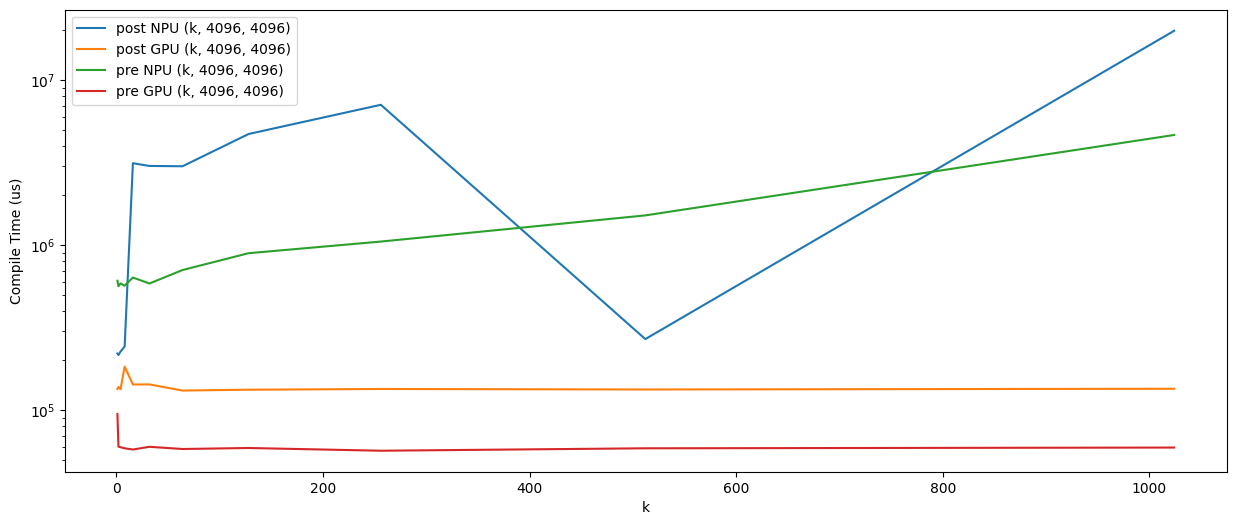

In [13]:
import matplotlib.pyplot as plt
import numpy as np    

x = keys1
npu_y1 = [d[1] for d in npu_data1]
gpu_y1 = [d[1] for d in gpu_data1]
npu_y2 = [d[1] for d in npu_data2]
gpu_y2 = [d[1] for d in gpu_data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='post NPU (k, 4096, 4096)')
ax.plot(x, gpu_y1, label='post GPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='pre NPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='pre GPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.set_yscale('log')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096]

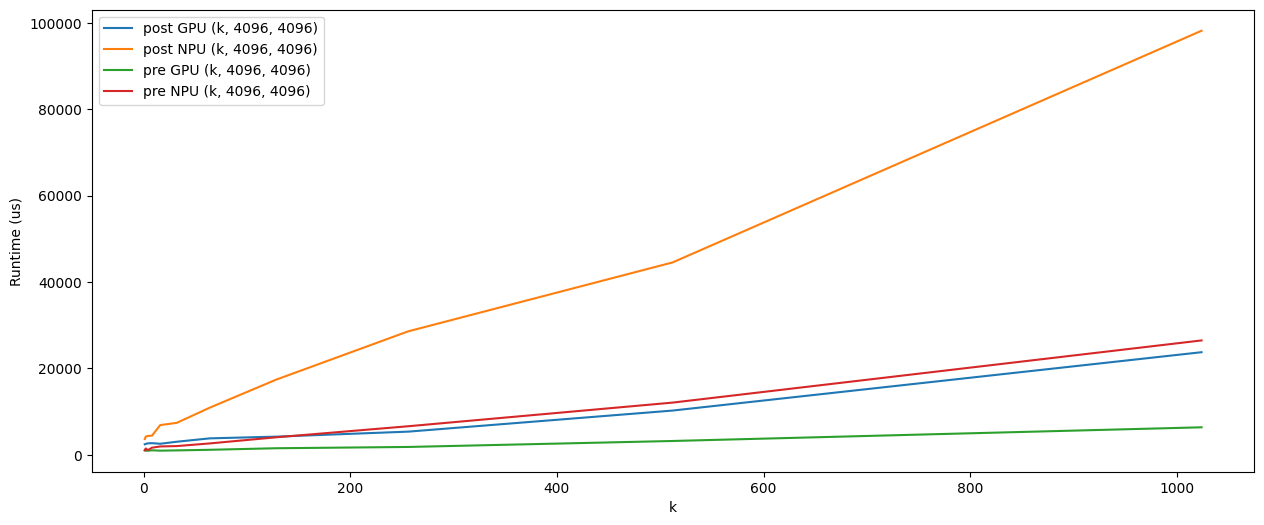

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = keys1
gpu_y1 = [d[2] for d in gpu_data1]
npu_y1 = [d[2] for d in npu_data1]
gpu_y2 = [d[2] for d in gpu_data2]
npu_y2 = [d[2] for d in npu_data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y1, label='post GPU (k, 4096, 4096)')
ax.plot(x, npu_y1, label='post NPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='pre GPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='pre NPU (k, 4096, 4096)')
ax.set_xlabel('k')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [1024, 4096] * [4096, 4096]

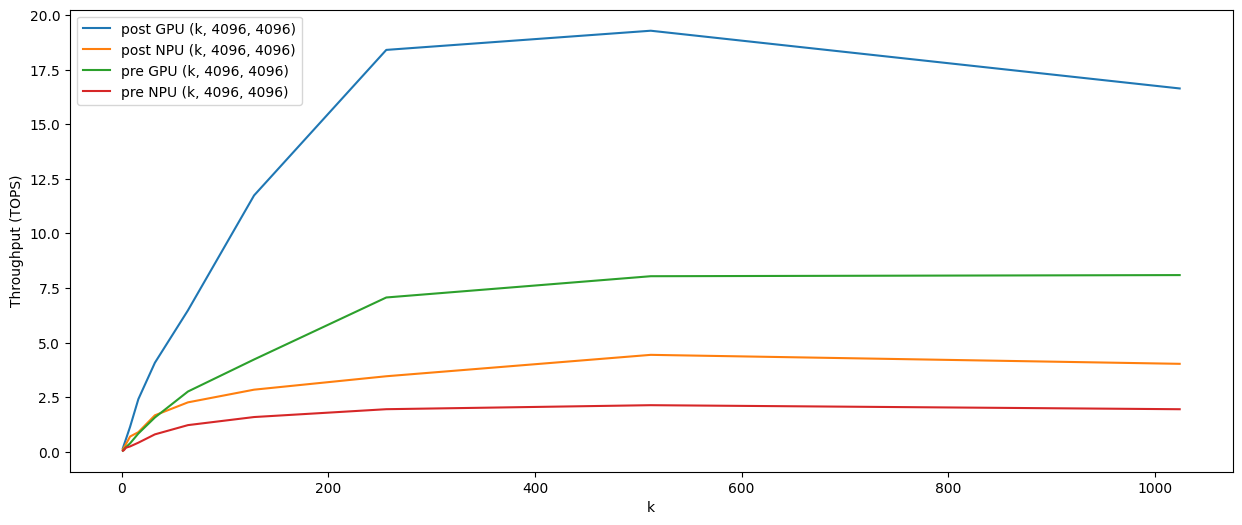

In [15]:
gpu_y1 = [d[3] for d in gpu_data1]
npu_y1 = [d[3] for d in npu_data1]
gpu_y2 = [d[3] for d in gpu_data2]
npu_y2 = [d[3] for d in npu_data2]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y1, label='post GPU (k, 4096, 4096)')
ax.plot(x, npu_y1, label='post NPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='pre GPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='pre NPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()

## Power (mW)
### [1024, 4096] * [4096, 4096]

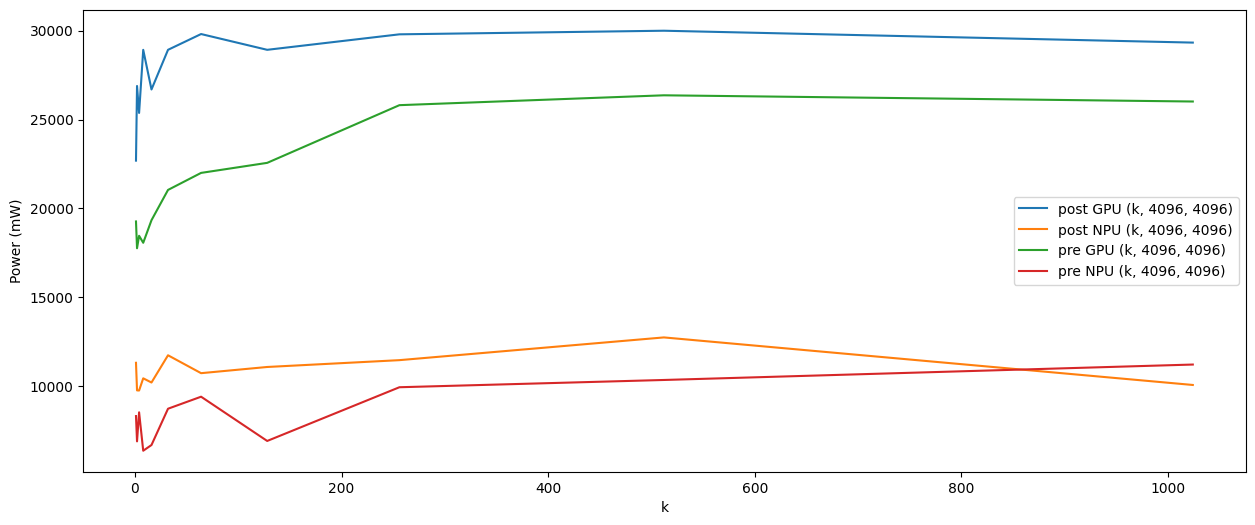

In [16]:
gpu_y1 = [d[4] for d in gpu_data1]
npu_y1 = [d[4] for d in npu_data1]
gpu_y2 = [d[4] for d in gpu_data2]
npu_y2 = [d[4] for d in npu_data2]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y1, label='post GPU (k, 4096, 4096)')
ax.plot(x, npu_y1, label='post NPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='pre GPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='pre NPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Power (mW)')
ax.legend()
plt.show()

## Throughput/Power (TOPS/mW)
### [k, 4096] * [4096, 4096]

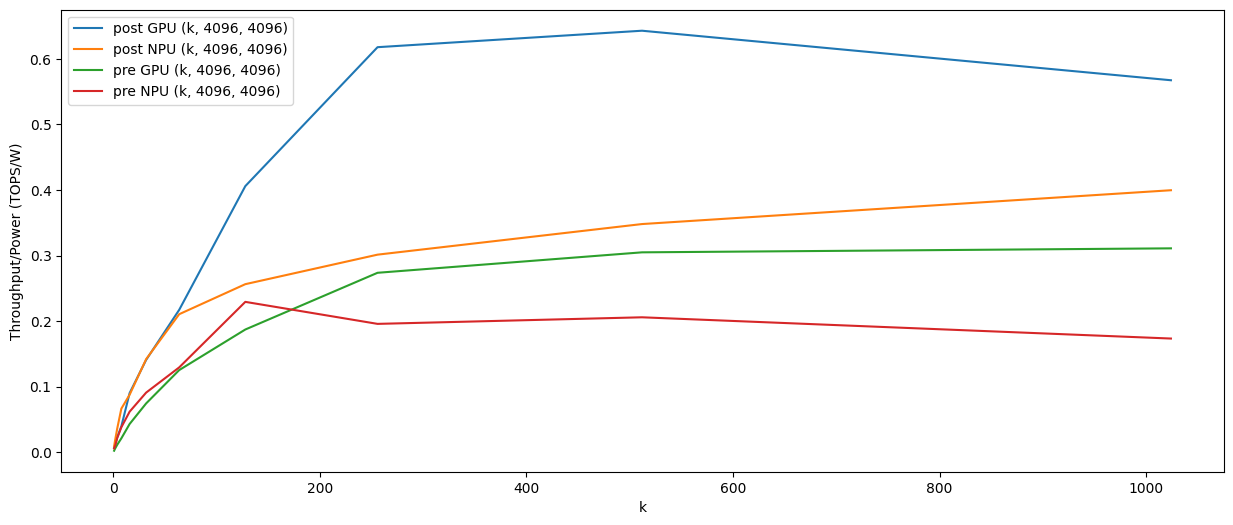

In [17]:
gpu_y1 = [d[3] for d in gpu_data1]
npu_y1 = [d[3] for d in npu_data1]
gpu_y11 = [d[4] for d in gpu_data1]
npu_y11 = [d[4] for d in npu_data1]
gpu_y2 = [d[3] for d in gpu_data2]
npu_y2 = [d[3] for d in npu_data2]
gpu_y22 = [d[4] for d in gpu_data2]
npu_y22 = [d[4] for d in npu_data2]

gpu_ratio = np.array(gpu_y1) / np.array(gpu_y11) * 1000
npu_ratio = np.array(npu_y1) / np.array(npu_y11) * 1000
gpu_ratio2 = np.array(gpu_y2) / np.array(gpu_y22) * 1000
npu_ratio2 = np.array(npu_y2) / np.array(npu_y22) * 1000
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_ratio, label='post GPU (k, 4096, 4096)')
ax.plot(x, npu_ratio, label='post NPU (k, 4096, 4096)')
ax.plot(x, gpu_ratio2, label='pre GPU (k, 4096, 4096)')
ax.plot(x, npu_ratio2, label='pre NPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Throughput/Power (TOPS/W)')
ax.legend()
plt.show()